In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

import joblib
import os

In [6]:
df = pd.read_csv(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\datasets\processed\traffic_feature_engineered.csv"
)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,...,weather_score,temperature_category,traffic_previous_hour,traffic_rolling_mean,traffic_rolling_max,traffic_rolling_min,traffic_std,traffic_change,traffic_growth,congestion
0,3,288.28,0.0,0.0,40,1,24,2012-10-02 09:00:00,5545,2012,...,2.00,2,5545.0,4942.666667,5545.0,4516.0,536.520581,-0.185573,-1029.0,3
1,3,289.36,0.0,0.0,75,1,2,2012-10-02 10:00:00,4516,2012,...,3.75,2,5545.0,4942.666667,5545.0,4516.0,536.520581,-0.185573,-1029.0,0
2,3,289.58,0.0,0.0,90,1,19,2012-10-02 11:00:00,4767,2012,...,4.50,2,4516.0,4942.666667,5545.0,4516.0,536.520581,0.055580,251.0,0
3,3,290.13,0.0,0.0,90,1,19,2012-10-02 12:00:00,5026,2012,...,4.50,2,4767.0,4769.666667,5026.0,4516.0,255.010457,0.054332,259.0,3
4,3,291.14,0.0,0.0,75,1,2,2012-10-02 13:00:00,4918,2012,...,3.75,2,5026.0,4903.666667,5026.0,4767.0,130.093556,-0.021488,-108.0,0


In [7]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print(df.info())

Dataset Shape
(48187, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48187 entries, 0 to 48186
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   holiday                48187 non-null  int64  
 1   temp                   48187 non-null  float64
 2   rain_1h                48187 non-null  float64
 3   snow_1h                48187 non-null  float64
 4   clouds_all             48187 non-null  int64  
 5   weather_main           48187 non-null  int64  
 6   weather_description    48187 non-null  int64  
 7   date_time              48187 non-null  object 
 8   traffic_volume         48187 non-null  int64  
 9   year                   48187 non-null  int64  
 10  month                  48187 non-null  int64  
 11  day                    48187 non-null  int64  
 12  hour                   48187 non-null  int64  
 13  day_of_week            48187 non-null  int64  
 14  week                   48187

In [8]:
X = df.drop(
    columns=[
        "traffic_volume",
        "date_time"
    ]
)

y = df["traffic_volume"]

In [9]:
import numpy as np

# Replace infinity values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.bfill().ffill()

# Final safety check
X = X.fillna(0)

In [10]:
print("=" * 60)
print("NaN values in each column")
print("=" * 60)

print(X.isnull().sum())
import numpy as np

print("=" * 60)
print("Infinity values")
print("=" * 60)

print(np.isinf(X).sum())
print(X.dtypes)
print("NaN :", X.isnull().sum().sum())

print("Infinity :", np.isinf(X).sum().sum())

NaN values in each column
holiday                  0
temp                     0
rain_1h                  0
snow_1h                  0
clouds_all               0
weather_main             0
weather_description      0
year                     0
month                    0
day                      0
hour                     0
day_of_week              0
week                     0
is_weekend               0
is_peak_hour             0
minute                   0
week_of_year             0
quarter                  0
is_night                 0
rush_hour                0
weather_score            0
temperature_category     0
traffic_previous_hour    0
traffic_rolling_mean     0
traffic_rolling_max      0
traffic_rolling_min      0
traffic_std              0
traffic_change           0
traffic_growth           0
congestion               0
dtype: int64
Infinity values
holiday                  0
temp                     0
rain_1h                  0
snow_1h                  0
clouds_all               0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (38549, 30)
Testing Samples : (9638, 30)


In [12]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
lr_prediction = lr.predict(X_test)

In [14]:
lr_mae = mean_absolute_error(
    y_test,
    lr_prediction
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

lr_r2 = r2_score(
    y_test,
    lr_prediction
)

print("="*60)
print("Linear Regression")

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R2 :", lr_r2)

Linear Regression
MAE : 0.11806347548753773
RMSE : 0.7415208971009017
R2 : 0.9999998624653675


In [15]:
rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf_prediction = rf.predict(
    X_test
)

In [17]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("="*60)
print("Random Forest")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 :", rf_r2)

Random Forest
MAE : 13.505592965345505
RMSE : 46.644147255047436
R2 : 0.9994557986718


In [18]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
24,traffic_rolling_max,0.803614
29,congestion,0.151356
27,traffic_change,0.021341
25,traffic_rolling_min,0.016748
10,hour,0.002339
22,traffic_previous_hour,0.002019
28,traffic_growth,0.001913
23,traffic_rolling_mean,0.000247
26,traffic_std,0.000130
18,is_night,0.000042


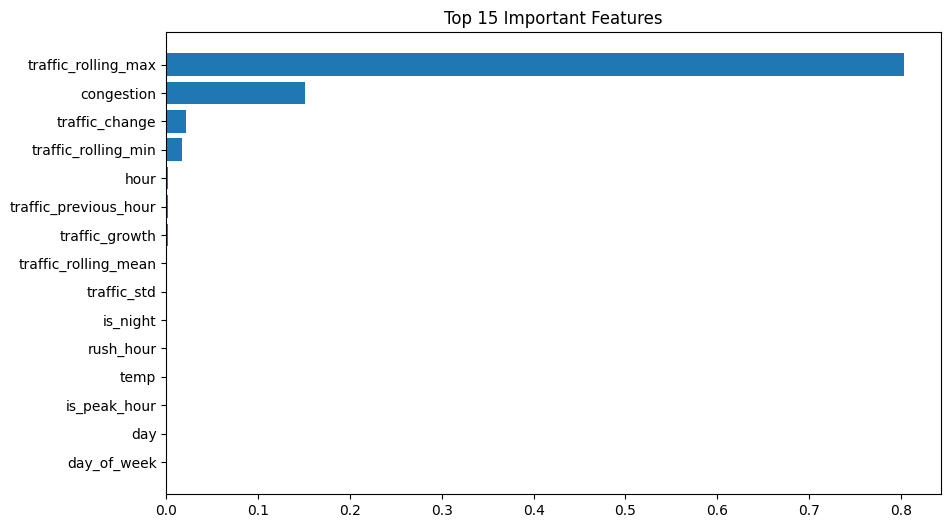

In [19]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"][:15],

    importance["Importance"][:15]

)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [20]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        lr_mae,

        rf_mae

    ],

    "RMSE":[

        lr_rmse,

        rf_rmse

    ],

    "R2":[

        lr_r2,

        rf_r2

    ]

})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.118063,0.741521,1.000000
1,Random Forest,13.505593,46.644147,0.999456


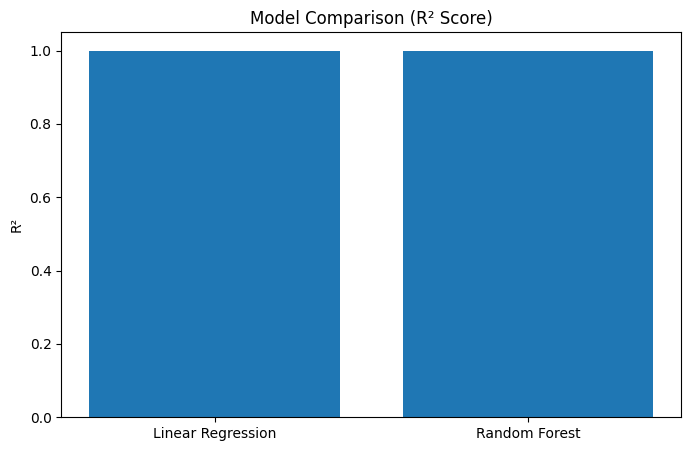

In [21]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["R2"]

)

plt.title("Model Comparison (R² Score)")

plt.ylabel("R²")

plt.show()

In [22]:
joblib.dump(

    rf,

    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\traffic_random_forest.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
joblib.dump(

    list(X.columns),

    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\feature_columns.pkl"

)

['C:\\AI-Powered-Intelligent-Traffic-Management-System\\models\\feature_columns.pkl']

In [24]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

print(rf)
print(rf_prediction)

       holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
44749        3  295.42     0.00      0.0          90             1   
8090         3  291.21     0.00      0.0          64             5   
33250        3  276.82     0.00      0.0          90             2   
33813        3  282.15     0.00      0.0          75             1   
18152        3  293.38     0.00      0.0           1             0   
...        ...     ...      ...      ...         ...           ...   
11284        3  248.79     0.00      0.0          40             1   
44732        3  288.44     0.00      0.0           1             0   
38158        3  286.88     0.00      0.0           1             0   
860          3  269.24     0.00      0.0          20             1   
15795        3  296.76     0.32      0.0          75             6   

       weather_description  year  month  day  ...  weather_score  \
44749                   19  2018      6    7  ...           4.50   
8090                   

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    rf_prediction
)

mse = mean_squared_error(
    y_test,
    rf_prediction
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    rf_prediction
)

evs = explained_variance_score(
    y_test,
    rf_prediction
)

print("="*60)
print("MODEL EVALUATION")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"Explained Variance : {evs:.4f}")

MODEL EVALUATION
MAE  : 13.51
MSE  : 2175.68
RMSE : 46.64
R²   : 0.9995
Explained Variance : 0.9995


In [26]:
comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": rf_prediction

})

comparison.head(20)

,Actual,Predicted
1162,4924,4847.865
27023,3800,3799.435
21595,5124,5327.790
25840,4986,5152.185
17240,4735,4717.750
29102,3055,3067.445
45025,1724,1720.075
38046,4028,4024.725
30893,3397,3397.460
22182,5597,5588.475


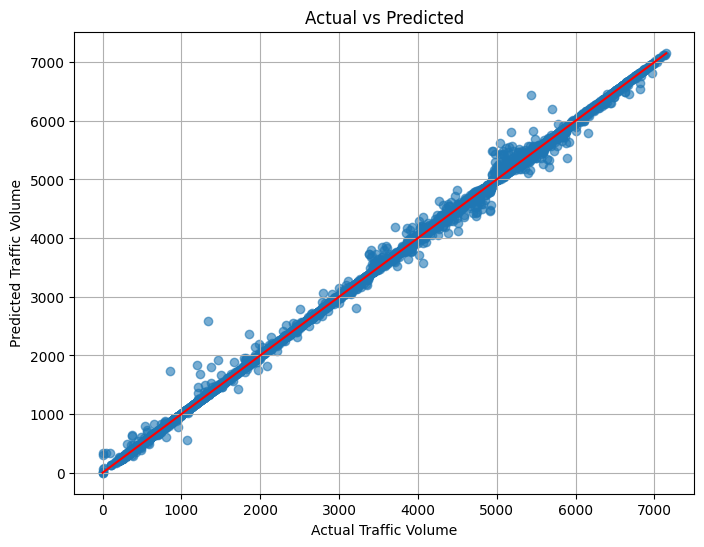

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_prediction,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Traffic Volume")

plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

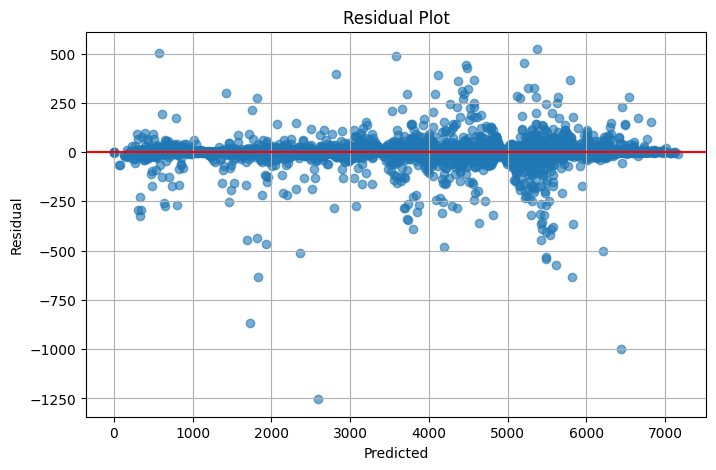

In [28]:
residuals = y_test - rf_prediction

plt.figure(figsize=(8,5))

plt.scatter(
    rf_prediction,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

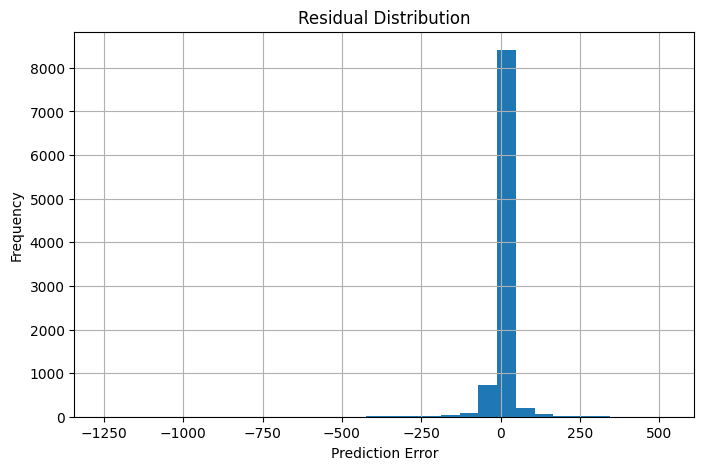

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [30]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
24,traffic_rolling_max,0.803614
29,congestion,0.151356
27,traffic_change,0.021341
25,traffic_rolling_min,0.016748
10,hour,0.002339
22,traffic_previous_hour,0.002019
28,traffic_growth,0.001913
23,traffic_rolling_mean,0.000247
26,traffic_std,0.000130
18,is_night,0.000042


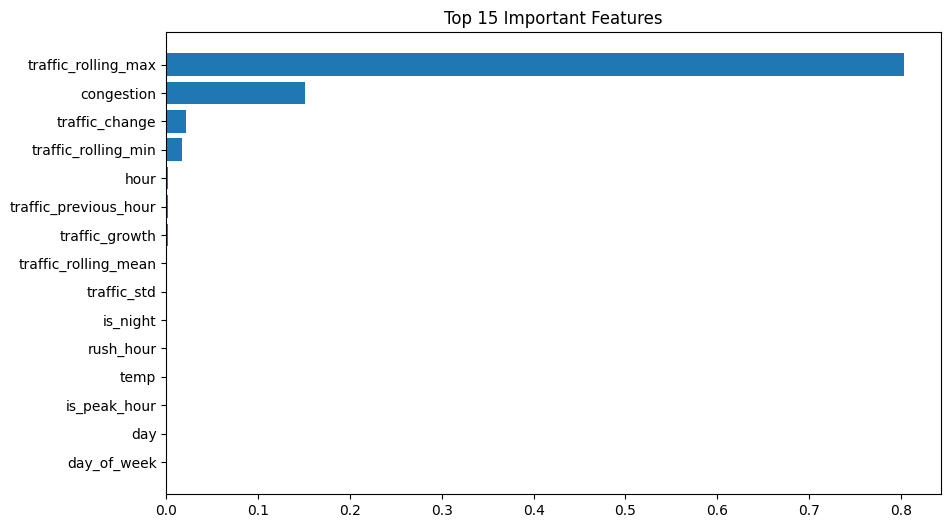

In [31]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [32]:
summary = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R2",

        "Explained Variance"

    ],

    "Value":[

        mae,

        mse,

        rmse,

        r2,

        evs

    ]

})

summary

,Metric,Value
0,MAE,13.505593
1,MSE,2175.676473
2,RMSE,46.644147
3,R2,0.999456
4,Explained Variance,0.999456


In [33]:
summary.to_csv(

    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\evaluation_report.csv",

    index=False

)

print("Evaluation report saved successfully.")

Evaluation report saved successfully.


In [34]:
comparison.to_csv(

    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\predictions.csv",

    index=False

)

print("Predictions saved successfully.")

Predictions saved successfully.


In [35]:
os.makedirs(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models",
    exist_ok=True
)

print("Models folder is ready.")

Models folder is ready.


In [36]:
joblib.dump(
    rf,
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\traffic_random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [37]:
joblib.dump(
    list(X.columns),
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [38]:
loaded_model = joblib.load(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\traffic_random_forest.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [39]:
feature_columns = joblib.load(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\feature_columns.pkl"
)

print(feature_columns)

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'year', 'month', 'day', 'hour', 'day_of_week', 'week', 'is_weekend', 'is_peak_hour', 'minute', 'week_of_year', 'quarter', 'is_night', 'rush_hour', 'weather_score', 'temperature_category', 'traffic_previous_hour', 'traffic_rolling_mean', 'traffic_rolling_max', 'traffic_rolling_min', 'traffic_std', 'traffic_change', 'traffic_growth', 'congestion']


In [40]:
loaded_prediction = loaded_model.predict(X_test)

print("First 10 Predictions:")

print(loaded_prediction[:10])

First 10 Predictions:
[4847.865 3799.435 5327.79  5152.185 4717.75  3067.445 1720.075 4024.725
 3397.46  5588.475]


In [41]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": loaded_prediction
})

comparison.head(20)

,Actual,Prediction
0,4924,4847.865
1,3800,3799.435
2,5124,5327.790
3,4986,5152.185
4,4735,4717.750
5,3055,3067.445
6,1724,1720.075
7,4028,4024.725
8,3397,3397.460
9,5597,5588.475


In [42]:
comparison.to_csv(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\prediction_results.csv",
    index=False
)

print("Prediction results saved.")

Prediction results saved.


In [43]:
import json
from datetime import datetime

metadata = {
    "model": "Random Forest Regressor",
    "version": "1.0.0",
    "trained_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": "Metro Interstate Traffic Volume",
    "samples": len(df),
    "features": len(X.columns),
    "target": "traffic_volume"
}

with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved.")

Metadata saved.


In [44]:
joblib.dump(
    rf,
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\models\random_forest.pkl"
)

['C:\\AI-Powered-Intelligent-Traffic-Management-System\\models\\random_forest.pkl']